In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
# Data processing
# ==============================================================================

from skforecast.datasets import fetch_dataset

# Plots
# ==============================================================================
from skforecast.plot import set_dark_theme
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf
import plotly.graph_objects as go
import plotly.io as pio
import plotly.offline as poff
pio.templates.default = "seaborn"
poff.init_notebook_mode(connected=True)
plt.style.use('seaborn-v0_8-darkgrid')

# Modelling and Forecasting
# ==============================================================================
import xgboost
import skforecast
import sklearn
from xgboost import XGBRegressor
from sklearn.feature_selection import RFECV
from skforecast.recursive import ForecasterRecursive
from skforecast.model_selection import TimeSeriesFold
from skforecast.model_selection import bayesian_search_forecaster
from skforecast.model_selection import backtesting_forecaster
from skforecast.feature_selection import select_features
from skforecast.preprocessing import RollingFeatures
import shap

# Warnings configuration
# ==============================================================================
import warnings
warnings.filterwarnings('once')

# import packages for hyperparameters tuning
from hyperopt import STATUS_OK, Trials, fmin, hp, tpe

In [2]:
file_path = r"C:\Documents\ML\Projet 1 - AQ\air-quality-data-paris.csv"

df = pd.read_csv(file_path, parse_dates=["date"], skipinitialspace=True)
df = df.drop(columns = ["pm10","no2","o3","so2","co"])
df_aq = df[["date", "pm25"]]
df_aq[["country","city","street","url"]] = ["france","paris","boulevard-peripherique-est","https://api.waqi.info/feed/@3088"]

6 axes: validity, accuracy, consistency, uniqueness, update frequency, completeness

In [5]:
#missing values
df.isna().sum()
df.dropna(inplace=True)

In [6]:
import openmeteo_requests

import pandas as pd
import requests_cache
from retry_requests import retry

# Setup the Open-Meteo API client with cache and retry on error
cache_session = requests_cache.CachedSession('.cache', expire_after = 3600)
retry_session = retry(cache_session, retries = 5, backoff_factor = 0.2)
openmeteo = openmeteo_requests.Client(session = retry_session)

# Make sure all required weather variables are listed here
# The order of variables in hourly or daily is important to assign them correctly below
url = "https://historical-forecast-api.open-meteo.com/v1/forecast"
params = {
	"latitude": 48.8534,
	"longitude": 2.3488,
	"start_date": "2016-01-01",
	"end_date": "2026-03-17",
	"daily": ["temperature_2m_mean", "wind_speed_10m_max", "wind_direction_10m_dominant", "precipitation_sum", "relative_humidity_2m_mean", "uv_index_max"],
	"hourly": "temperature_2m",
	"timezone": "GMT",
}
responses = openmeteo.weather_api(url, params = params)

# Process first location. Add a for-loop for multiple locations or weather models
response = responses[0]
print(f"Coordinates: {response.Latitude()}°N {response.Longitude()}°E")
print(f"Elevation: {response.Elevation()} m asl")
print(f"Timezone: {response.Timezone()}{response.TimezoneAbbreviation()}")
print(f"Timezone difference to GMT+0: {response.UtcOffsetSeconds()}s")

# Process hourly data. The order of variables needs to be the same as requested.
hourly = response.Hourly()
hourly_temperature_2m = hourly.Variables(0).ValuesAsNumpy()

hourly_data = {"date": pd.date_range(
	start = pd.to_datetime(hourly.Time(), unit = "s", utc = True),
	end =  pd.to_datetime(hourly.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = hourly.Interval()),
	inclusive = "left"
)}

hourly_data["temperature_2m"] = hourly_temperature_2m

hourly_dataframe = pd.DataFrame(data = hourly_data)
print("\nHourly data\n", hourly_dataframe)

# Process daily data. The order of variables needs to be the same as requested.
daily = response.Daily()
daily_temperature_2m_mean = daily.Variables(0).ValuesAsNumpy()
daily_wind_speed_10m_max = daily.Variables(1).ValuesAsNumpy()
daily_wind_direction_10m_dominant = daily.Variables(2).ValuesAsNumpy()
daily_precipitation_sum = daily.Variables(3).ValuesAsNumpy()
daily_relative_humidity_2m_mean = daily.Variables(4).ValuesAsNumpy()
daily_uv_index_max = daily.Variables(5).ValuesAsNumpy()

daily_data = {"date": pd.date_range(
	start = pd.to_datetime(daily.Time(), unit = "s", utc = True),
	end =  pd.to_datetime(daily.TimeEnd(), unit = "s", utc = True),
	freq = pd.Timedelta(seconds = daily.Interval()),
	inclusive = "left"
)}

daily_data["temperature_2m_mean"] = daily_temperature_2m_mean
daily_data["wind_speed_10m_max"] = daily_wind_speed_10m_max
daily_data["wind_direction_10m_dominant"] = daily_wind_direction_10m_dominant
daily_data["precipitation_sum"] = daily_precipitation_sum
daily_data["relative_humidity_2m_mean"] = daily_relative_humidity_2m_mean
daily_data["uv_index_max"] = daily_uv_index_max

daily_dataframe = pd.DataFrame(data = daily_data)
print("\nDaily data\n", daily_dataframe)


Coordinates: 48.86000061035156°N 2.3399996757507324°E
Elevation: 43.0 m asl
Timezone: NoneNone
Timezone difference to GMT+0: 0s

Hourly data
                            date  temperature_2m
0     2016-01-01 00:00:00+00:00             NaN
1     2016-01-01 01:00:00+00:00             NaN
2     2016-01-01 02:00:00+00:00             NaN
3     2016-01-01 03:00:00+00:00             NaN
4     2016-01-01 04:00:00+00:00             NaN
...                         ...             ...
89491 2026-03-17 19:00:00+00:00         14.3695
89492 2026-03-17 20:00:00+00:00         13.3695
89493 2026-03-17 21:00:00+00:00         12.3695
89494 2026-03-17 22:00:00+00:00         11.6195
89495 2026-03-17 23:00:00+00:00         10.8695

[89496 rows x 2 columns]

Daily data
                           date  temperature_2m_mean  wind_speed_10m_max  \
0    2016-01-01 00:00:00+00:00                  NaN                 NaN   
1    2016-01-02 00:00:00+00:00                  NaN                 NaN   
2    2016-01-03 00

c:\Users\samyh\anaconda3\Lib\site-packages\url_normalize\normalize_host.py:35: DeprecationWarning: Transitional processing has been removed from UTS #46. The transitional argument will be removed in a future version.
  idna.encode(p, uts46=True, transitional=True).decode(charset)


In [7]:
daily_dataframe["date"] = pd.to_datetime(daily_dataframe["date"]).dt.tz_localize(None)
df = df.merge(daily_dataframe, how = "right", on =["date"])
df.dropna(inplace = True)

In [8]:
#lag 1 day
df["pm25_1day"] = df["pm25"].shift(1)

#lag 2 day
#df["pm25_2day"] = df["pm25"].shift(2)

#création feature rolling mean
#df["pm25_roll"] = df["pm25"].shift(1).rolling(window=3).mean()

In [9]:
import os
from datetime import timedelta

test_days = int(os.getenv("TEST_DAYS","60"))
min_train_days = int(os.getenv('MIN_TRAIN_DAYS', '180'))
df_temp = df.copy() #copie du df pour bosser


# Ensure date column is datetime
df_temp['date'] = pd.to_datetime(df_temp['date'])

# Sort by date to find the most recent available data
df_temp_sorted = df_temp.sort_values("date")

# Get the most recent date in the available data
max_date = df_temp_sorted['date'].max()
min_date = df_temp_sorted['date'].min()
total_days = (max_date - min_date).days

print(f"Data available from {min_date.date()} to {max_date.date()} ({total_days} days)")

# Calculate test_start date: take the last test_days from the most recent available date
test_start = max_date - timedelta(days=test_days - 1)  # -1 to include max_date in test set

# Calculate actual training days
train_days = (test_start - min_date).days

print(f"Proposed split:")
print(f"  Training: {min_date.date()} to {test_start.date()} ({train_days} days)")
print(f"  Testing:  {test_start.date()} to {max_date.date()} ({test_days} days)")


Data available from 2021-03-23 to 2026-03-17 (1820 days)
Proposed split:
  Training: 2021-03-23 to 2026-01-17 (1761 days)
  Testing:  2026-01-17 to 2026-03-17 (60 days)


In [14]:
#training
data_train = df_temp_sorted[df_temp_sorted["date"] <= test_start]
X_train, y_train = data_train.drop("pm25", axis=1), data_train["pm25"]

# test : on exclut test_start (déjà dans le train) — exog doit démarrer J+1
data_test = df_temp_sorted[df_temp_sorted["date"] > test_start]
X_test, y_test = data_test.drop("pm25", axis=1), data_test["pm25"]


#cols exogene
exog_cols = ["temperature_2m_mean", "wind_speed_10m_max","precipitation_sum",
             "wind_direction_10m_dominant", "relative_humidity_2m_mean", "uv_index_max"]


#bloc data train
# Interpolation temporelle des NaN intercalés dans pm25 (lacunes capteur ≤ 3 jours)
# Au-delà de 3 jours consécutifs, on laisse NaN pour éviter d'inventer des pics/creux

data_train = data_train.set_index("date").asfreq('D')
nan_before = data_train["pm25"].isna().sum()
data_train["pm25"] = data_train["pm25"].interpolate(method='time', limit=3)
nan_after = data_train["pm25"].isna().sum()
print(f"pm25 — NaN avant interpolation : {nan_before}, après : {nan_after} (comblés : {nan_before - nan_after})")
exog_train = data_train[exog_cols]
exog_train = exog_train.interpolate(method='time', limit=3)


#bloc data test
data_test = data_test.set_index("date").asfreq('D')
exog_test = data_test[exog_cols]

pm25 — NaN avant interpolation : 19, après : 0 (comblés : 19)


In [15]:
#drop features
X_features = X_train.drop(columns=['date'])
X_test_features = X_test.drop(columns=['date'])

In [16]:
from xgboost import XGBRegressor
# Creating an instance of the XGBoost Regressor
xgb_regressor = XGBRegressor()

# Fitting the XGBoost Regressor to the training data
xgb_regressor.fit(X_features, y_train)


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

In [17]:
from xgboost import plot_importance
from sklearn.metrics import mean_squared_error, r2_score
# Predicting target values on the test set
y_pred = xgb_regressor.predict(X_test_features)

# Calculating Mean Squared Error (MSE) using sklearn
mse = mean_squared_error(y_test, y_pred)
print("MSE:", mse)

# Calculating R squared using sklearn
r2 = r2_score(y_test, y_pred)
print("R squared:", r2)

MSE: 128.67979813223897
R squared: 0.6469699775711729


<Axes: title={'center': 'Feature importance'}, xlabel='Importance score', ylabel='Features'>

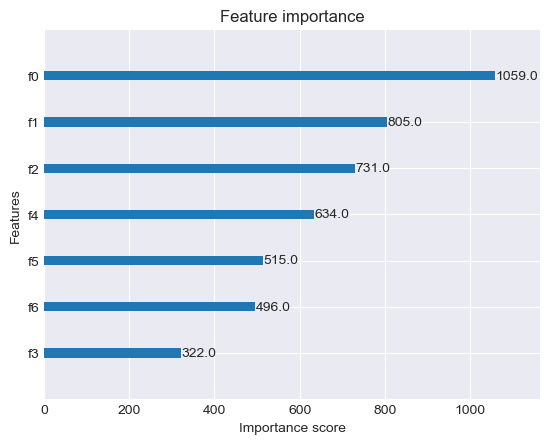

In [18]:
plot_importance(xgb_regressor)

In [19]:
##plot time series

# Interactive plot of time series
# ==============================================================================
fig = go.Figure()
fig.add_trace(go.Scatter(x=data_train.index, y=data_train['pm25'], mode='lines', name='Train'))
fig.add_trace(go.Scatter(x=data_test.index, y=data_test['pm25'], mode='lines', name='Test'))
fig.update_layout(
    title  = 'Concentration of Pm25',
    xaxis_title="Time",
    yaxis_title="Concentration",
    legend_title="Partition:",
    width=800,
    height=400,
    margin=dict(l=20, r=20, t=35, b=20),
    legend=dict(orientation="h", yanchor="top", y=1, xanchor="left", x=0.001)
)
#fig.update_xaxes(rangeslider_visible=True)
fig.show()

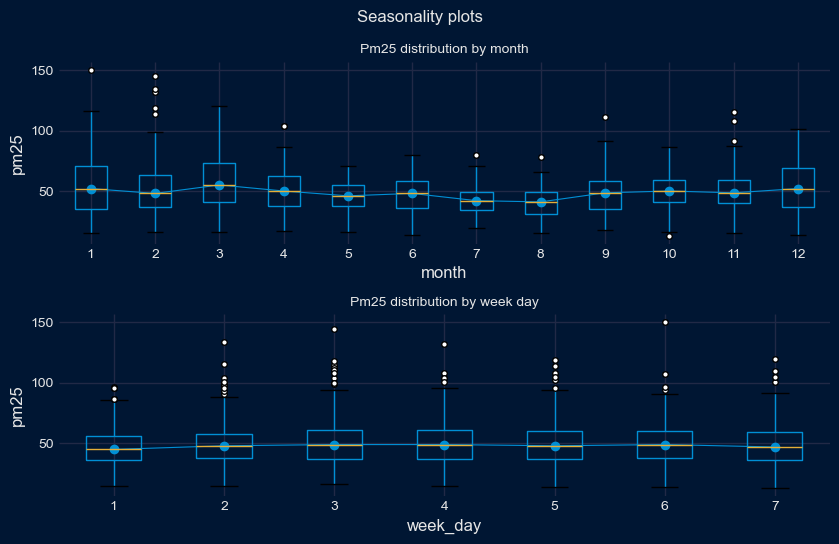

In [20]:
data = df.copy()

# Annual, weekly and daily seasonality
# ==============================================================================
set_dark_theme()
fig, axs = plt.subplots(2, 1, figsize=(8.5, 5.5), sharex=False, sharey=True)
axs = axs.ravel()
flierprops=dict(marker='o', markerfacecolor='white', markeredgecolor='black', markersize=4)
    
# Users distribution by month
data['month'] = data["date"].dt.month
data.boxplot(column='pm25', by='month', ax=axs[0], flierprops=flierprops)
data.groupby('month')['pm25'].median().plot(style='o-', linewidth=0.8, ax=axs[0])
axs[0].set_ylabel('pm25')
axs[0].set_title('Pm25 distribution by month', fontsize=10)

# Users distribution by week day
data['week_day'] = data["date"].dt.day_of_week + 1
data.boxplot(column='pm25', by='week_day', ax=axs[1], flierprops=flierprops)
data.groupby('week_day')['pm25'].median().plot(style='o-', linewidth=0.8, ax=axs[1])
axs[1].set_ylabel('pm25')
axs[1].set_title('Pm25 distribution by week day', fontsize=10)


fig.suptitle("Seasonality plots", fontsize=12)
fig.tight_layout()

#legere baisse en été

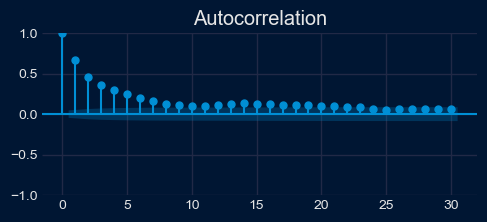

In [21]:
# Autocorrelation plot
# ==============================================================================
fig, ax = plt.subplots(figsize=(5, 2))
plot_acf(data['pm25'], ax=ax, lags=30)
plt.show()

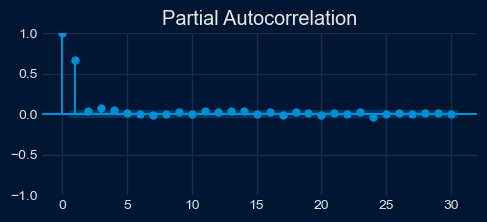

In [22]:
# Partial autocorrelation plot
# ==============================================================================

fig, ax = plt.subplots(figsize=(5, 2))
plot_pacf(data['pm25'], ax=ax, lags=30, method='ywm')
plt.show()

In [24]:
# Create forecaster
# ==============================================================================
window_features = RollingFeatures(stats=["mean"], window_sizes=30)
forecaster = ForecasterRecursive(
                estimator       = XGBRegressor(random_state=15926, enable_categorical=True),
                lags            = 7,
                window_features = window_features
             )



# Train forecaster avec variables exogènes météo
# ==============================================================================
forecaster.fit(y=data_train["pm25"], exog=exog_train)
forecaster


=================== 
ForecasterRecursive 
=================== 
Estimator: XGBRegressor 
Lags: [1 2 3 4 5 6 7] 
Window features: ['roll_mean_30'] 
Window size: 30 
Series name: pm25 
Exogenous included: True 
Exogenous names: 
    temperature_2m_mean, wind_speed_10m_max, precipitation_sum,
    wind_direction_10m_dominant, relative_humidity_2m_mean, uv_index_max 
Categorical features: auto 
Transformer for y: None 
Transformer for exog: None 
Weight function included: False 
Differentiation order: None 
Drop NaN from series: False 
Training range: [Timestamp('2021-03-23 00:00:00'), Timestamp('2026-01-17 00:00:00')] 
Training index type: DatetimeIndex 
Training index frequency: <Day> 
Estimator parameters: 
    {'objective': 'reg:squarederror', 'base_score': None, 'booster': None,
    'callbacks': None, 'colsample_bylevel': None, 'colsample_bynode': None,
    'colsample_bytree': None, 'device': None, 'early_stopping_rounds': None,
    'enable_categorical': False, 'eval_metric': None, 'feature_types': None,
    'feature_weights': None, 'gamma': None, 'grow_policy': None,
    'importance_type': None, 'interaction_constraints': None, 'learning_rate':
    None, 'max_bin': None, 'max_cat_threshold': None, 'max_cat_to_onehot': None,
    'max_delta_step': None, 'max_depth': None, 'max_leaves': None,
    'min_child_weight': None, 'missing': nan, 'monotone_constraints': None,
    'multi_strategy': None, 'n_estimators': None, 'n_jobs': None,
    'num_parallel_tree': None, 'random_state': 15926, 'reg_alpha': None,
    'reg_lambda': None, 'sampling_method': None, 'scale_pos_weight': None,
    'subsample': None, 'tree_method': None, 'validate_parameters': None,
    'verbosity': None} 
fit_kwargs: {} 
Creation date: 2026-06-10 16:21:17 
Last fit date: 2026-06-10 16:21:17 
Skforecast version: 0.22.0 
Python version: 3.12.13 
Forecaster id: None

In [25]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np
# Prédiction sur le test set
# ==============================================================================
predictions = forecaster.predict(steps=len(data_test), exog=exog_test)
# Valeurs réelles (data_test est déjà indexé par date après asfreq)
y_true = data_test["pm25"]
# Métriques
mae  = mean_absolute_error(y_true, predictions)
rmse = np.sqrt(mean_squared_error(y_true, predictions))
r2   = r2_score(y_true, predictions)
print("=" * 42)
print(f"  Test set : {y_true.index[0].date()} → {y_true.index[-1].date()} ({len(y_true)} jours)")
print(f"  MAE  : {mae:.2f} µg/m³")
print(f"  RMSE : {rmse:.2f} µg/m³")
print(f"  R²   : {r2:.4f}")
print("=" * 42)
# Visualisation prédictions vs réel
# ==============================================================================
fig = go.Figure()
fig.add_trace(go.Scatter(x=data_train.index, y=data_train["pm25"],
                         mode='lines', name='Train', line=dict(color='steelblue')))
fig.add_trace(go.Scatter(x=y_true.index, y=y_true,
                         mode='lines', name='Réel (test)', line=dict(color='orange')))
fig.add_trace(go.Scatter(x=predictions.index, y=predictions,
                         mode='lines', name='Prédiction', line=dict(color='red', dash='dash')))
fig.update_layout(
    title="ForecasterRecursive — PM2.5 Paris : prédictions vs réel",
    xaxis_title="Date",
    yaxis_title="PM2.5 (µg/m³)",
    legend=dict(orientation="h", yanchor="top", y=1, xanchor="left", x=0.001),
    width=900, height=420,
    margin=dict(l=20, r=20, t=40, b=20)
)
fig.show()

  Test set : 2026-01-18 → 2026-03-17 (59 jours)
  MAE  : 10.97 µg/m³
  RMSE : 14.38 µg/m³
  R²   : 0.4329


In [ ]:
# ── Étape 1 : sélection de window_size par validation croisée temporelle ──────
# bayesian_search_forecaster ne supporte pas window_features comme hyperparamètre,
# on teste donc quelques valeurs candidates en amont.
import warnings
from skforecast.model_selection import backtesting_forecaster, TimeSeriesFold
from skforecast.recursive import ForecasterRecursive
from skforecast.preprocessing import RollingFeatures
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error
import numpy as np
warnings.filterwarnings('ignore')


window_sizes_candidates = [7, 14, 21, 30, 45, 60]
cv_ws = TimeSeriesFold(steps=30, initial_train_size=int(len(data_train) * 0.85), refit=False)
results_ws = {}

for ws in window_sizes_candidates:
    wf = RollingFeatures(stats=["mean"], window_sizes=ws)
    fc = ForecasterRecursive(
        estimator       = XGBRegressor(random_state=15926, enable_categorical=True),
        lags            = 7,
        window_features = wf
    )
    _, preds = backtesting_forecaster(
        forecaster = fc,
        y          = data_train["pm25"],
        exog       = exog_train,
        cv         = cv_ws,
        metric     = "mean_absolute_error",
        verbose    = False,
    )
    mae = mean_absolute_error(
        data_train["pm25"].iloc[-len(preds):], preds["pred"]
    )
    results_ws[ws] = mae
    print(f"  window_size={ws:>3}  →  MAE CV = {mae:.3f}")
best_ws = min(results_ws, key=results_ws.get)
print(f"\n✅ Meilleure window_size : {best_ws}  (MAE = {results_ws[best_ws]:.3f})")

  0%|          | 0/9 [00:00<?, ?it/s]

  window_size=  7  →  MAE CV = 10.053


  0%|          | 0/9 [00:00<?, ?it/s]

  window_size= 14  →  MAE CV = 10.971


  0%|          | 0/9 [00:00<?, ?it/s]

  window_size= 21  →  MAE CV = 10.049


  0%|          | 0/9 [00:00<?, ?it/s]

  window_size= 30  →  MAE CV = 9.862


  0%|          | 0/9 [00:00<?, ?it/s]

  window_size= 45  →  MAE CV = 9.400


  0%|          | 0/9 [00:00<?, ?it/s]

  window_size= 60  →  MAE CV = 8.753

✅ Meilleure window_size : 60  (MAE = 8.753)


## Optimisation des hyperparamètres

L'optimisation est découpée en deux étapes séquentielles, car `bayesian_search_forecaster` ne permet pas de passer `window_features` comme hyperparamètre (il ne peut pas reconstruire un objet `RollingFeatures` à la volée).

---

### Étape 1 — Sélection de `window_size` (cellule ci-dessus)

On teste 6 valeurs candidates — 7, 14, 21, 30, 45 et 60 jours — par backtesting glissant sur le train set (folds de 30 jours). La MAE de validation décroît régulièrement avec la fenêtre : une moyenne glissante sur 60 jours capte mieux la tendance de fond que des fenêtres courtes.

| window_size | MAE CV |
|---|---|
| 7 | 10.05 |
| 14 | 10.97 |
| 21 | 10.05 |
| 30 | 9.86 |
| 45 | 9.40 |
| **60** | **8.75** ✅ |

**`window_size = 60`** est retenu pour l'étape 2.

---

### Étape 2 — Recherche bayésienne lags + XGBoost (cellule ci-dessous)

Avec `window_size` fixé à 60, Optuna explore 60 combinaisons et optimise :

| Paramètre | Rôle |
|---|---|
| `lags` | Jours passés de PM2.5 passés en features (3 → 21) |
| `n_estimators` | Nombre d'arbres |
| `max_depth` | Profondeur des arbres |
| `learning_rate` | Taux d'apprentissage |
| `subsample` / `colsample_bytree` | Sous-échantillonnage (régularisation) |
| `reg_alpha` / `reg_lambda` | Régularisation L1 / L2 |
| `min_child_weight` | Poids minimum pour créer un nœud fils |

**Meilleure combinaison trouvée :** `lags = [1, 2, 3]`, `n_estimators = 524`, `max_depth = 3`, `learning_rate ≈ 0.018` — un modèle peu profond et à apprentissage lent, cohérent avec le faible signal à court terme du PM2.5.

**Résultats sur le test set après optimisation :**

| | Baseline (lags=7, ws=30) | Optimisé (lags=3, ws=60) | Gain |
|---|---|---|---|
| MAE | 10.97 µg/m³ | **9.30 µg/m³** | −15% |
| RMSE | 14.38 µg/m³ | **12.45 µg/m³** | −13% |
| R² | 0.43 | **0.57** | +33% |

In [ ]:
# ── Étape 2 : recherche bayésienne sur lags + hyperparamètres XGBoost ─────────
# window_size fixé au meilleur trouvé à l'étape 1
from skforecast.model_selection import bayesian_search_forecaster

cv_bayes = TimeSeriesFold(steps=30, initial_train_size=int(len(data_train) * 0.85), refit=False)

def search_space(trial):
    return {
        # Nombre de lags : de 3 à 21 jours (cycle hebdomadaire → mensuel)
        "lags": trial.suggest_int("lags", 3, 21),
        # Hyperparamètres XGBoost
        "n_estimators":     trial.suggest_int("n_estimators", 100, 600),
        "max_depth":        trial.suggest_int("max_depth", 3, 8),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-4, 10.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-4, 10.0, log=True),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
    }

forecaster_opt = ForecasterRecursive(
    estimator       = XGBRegressor(random_state=15926, enable_categorical=True),
    lags            = 7,
    window_features = RollingFeatures(stats=["mean"], window_sizes=best_ws)
)

results_bayes, best_trial = bayesian_search_forecaster(
    forecaster   = forecaster_opt,
    y            = data_train["pm25"],
    exog         = exog_train,
    cv           = cv_bayes,
    search_space = search_space,
    n_trials     = 60,
    metric       = "mean_absolute_error",
    return_best  = True,   # re-fit automatique avec les meilleurs params
    verbose      = False,
)

print("── Top 5 combinaisons ──────────────────────────────────")
display_cols = ["lags", "n_estimators", "max_depth", "learning_rate",
                "subsample", "mean_absolute_error"]
print(results_bayes.head(5)[display_cols].to_string(index=False))
print(f"\n✅ Meilleure MAE CV : {results_bayes['mean_absolute_error'].iloc[0]:.3f}")
print(f"   Lags optimaux    : {results_bayes['lags'].iloc[0]}")
print(f"   window_size      : {best_ws}")


# ── Évaluation finale sur le vrai test set ────────────────────────────────────
predictions_opt = forecaster_opt.predict(steps=len(data_test), exog=exog_test)
y_true = data_test["pm25"]
from sklearn.metrics import mean_squared_error, r2_score
mae_opt  = mean_absolute_error(y_true, predictions_opt)
rmse_opt = np.sqrt(mean_squared_error(y_true, predictions_opt))
r2_opt   = r2_score(y_true, predictions_opt)
print("\n── Résultats sur le test set (modèle optimisé) ─────────")
print(f"   MAE  : {mae_opt:.2f} µg/m³")
print(f"   RMSE : {rmse_opt:.2f} µg/m³")
print(f"   R²   : {r2_opt:.4f}")

  0%|          | 0/60 [00:00<?, ?it/s]

── Top 5 combinaisons ──────────────────────────────────
                                                           lags  n_estimators  max_depth  learning_rate  subsample  mean_absolute_error
                                                      [1, 2, 3]         524.0        3.0       0.018307   0.685672             8.281880
[1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]         542.0        6.0       0.065195   0.649497             8.299058
        [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]         565.0        6.0       0.092602   0.603639             8.345357
        [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16]         423.0        6.0       0.031253   0.672057             8.371073
                [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]         590.0        6.0       0.106299   0.635821             8.395595

✅ Meilleure MAE CV : 8.282
   Lags optimaux    : [1 2 3]
   window_size      : 60

── Résultats sur le test set (modèle optimi